<a href="https://colab.research.google.com/github/minbj1226/pytorch-basics/blob/main/07_Classify_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. 이미지 분류 실습에 사용한 데이터셋
- 이미지 분류 실습에 CIFAR-10 데이터셋을 사용

### 2. DataLoader 사용 이유
- DataLoader는 데이터를 batch 단위로 나누어 불러오고, 셔플 및 반복 처리를 쉽게 하기 위해 사용

### 3. CNN  모델의 구조
- Convolution layer, 활성화 함수, Pooling layer, Fully Connected layer로 구성

### 4. loss function과 optimizer 사용 방법
- loss function은 예측값과 정답값의 차이를 계산하고 optimizer는 계산된
gradient를 바탕으로 모델 파라미터를 업데이트

### 5. 학습과 평가 순서
- 학습 단계에서는 model.train()으로 학습을 진행하고, 학습이 끝난 후 model.eval()로 전환하여 평가를 수행

### 6. 최종 성능 확인
- 테스트 데이터셋에 대한 예측 결과를 바탕으로 accuracy를 계산하여 최종 성능을 확인


In [ ]:
import torch
import torchvision
from torchvision.transforms import v2

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:05<00:00, 33.7MB/s]


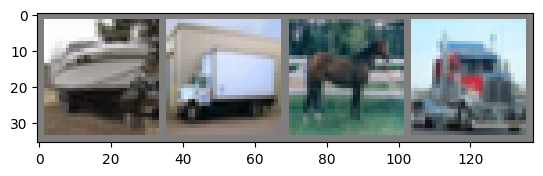

ship  truck horse truck


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
#Define a Convolutional Neural Network
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 6, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

net = Net()

In [ ]:
#Define a Loss function and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.215
[1,  4000] loss: 1.889
[1,  6000] loss: 1.691
[1,  8000] loss: 1.589
[1, 10000] loss: 1.543
[1, 12000] loss: 1.491
[2,  2000] loss: 1.422
[2,  4000] loss: 1.396
[2,  6000] loss: 1.371
[2,  8000] loss: 1.333
[2, 10000] loss: 1.320
[2, 12000] loss: 1.299
Finished Training


In [ ]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

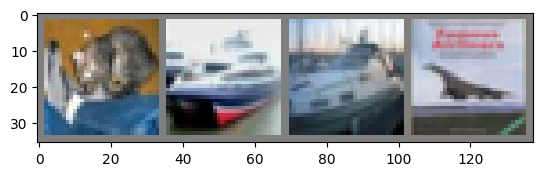

GroundTruth:  cat   ship  ship  plane


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [ ]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [ ]:
outputs = net(images)

In [ ]:
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   car   car   plane


In [ ]:
correct = 0
total = 0

with torch.no_grad():
  for data in testloader:
    images, labels = data
    outputs = net(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 54 %


In [ ]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
  for data in testloader:
    images, labels = data
    output = net(images)
    _, predictions = torch.max(output, 1)

    for label, prediction in zip(labels, predictions):
      if label == prediction:
        correct_pred[classes[label]] += 1
      total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
  accuracy = 100 * float(correct_count) / total_pred[classname]
  print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 65.6 %
Accuracy for class: car   is 82.6 %
Accuracy for class: bird  is 31.9 %
Accuracy for class: cat   is 23.9 %
Accuracy for class: deer  is 60.3 %
Accuracy for class: dog   is 37.0 %
Accuracy for class: frog  is 61.3 %
Accuracy for class: horse is 64.8 %
Accuracy for class: ship  is 65.6 %
Accuracy for class: truck is 50.4 %


In [ ]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

cuda


In [ ]:
net.to(device)

In [ ]:
inputs, labels = data[0].to(device), data[1].to(device)